In [1]:
import os
import shutil
import pandas as pd

# Update these paths to match where your files live in Google Drive
EXCEL_PATH = "/content/FETAL_PLANES_DB_data.xlsx"
IMAGES_DIR = "/content/drive/MyDrive/data/Images"
OUTPUT_DIR = "/content/drive/MyDrive/Sorted_Planes"

# Load spreadsheet
df = pd.read_excel(EXCEL_PATH)
filtered_df = df[df["Plane"].isin(["Fetal thorax", "Fetal abdomen"])]

# Setup output directories
thorax_dir = os.path.join(OUTPUT_DIR, "Fetal_thorax")
abdomen_dir = os.path.join(OUTPUT_DIR, "Fetal_abdomen")
os.makedirs(thorax_dir, exist_ok=True)
os.makedirs(abdomen_dir, exist_ok=True)

lookup = dict(
    zip(
        filtered_df["Image_name"].astype(str).str.strip(),
        filtered_df["Plane"],
    )
)

# Sort images
for filename in os.listdir(IMAGES_DIR):
    base_name, _ = os.path.splitext(filename)
    if base_name in lookup:
        plane = lookup[base_name]
        dest_folder = thorax_dir if plane == "Fetal thorax" else abdomen_dir
        shutil.copy2(
            os.path.join(IMAGES_DIR, filename),
            os.path.join(dest_folder, filename),
        )

print("Finished sorting images in Google Drive!")

Finished sorting images in Google Drive!


In [2]:
import cv2
import numpy as np
import albumentations as A

def preprocess_ultrasound(image_path, target_size=(256, 256)):
    """
    Preprocesses fetal echocardiogram images:
    1. Grayscale conversion
    2. Bilateral filtering for speckle noise removal
    3. CLAHE contrast enhancement
    4. Resizing
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # 1. Edge-preserving smoothing (Bilateral Filter)
    smoothed = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

    # 2. Contrast Limited Adaptive Histogram Equalization (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(smoothed)

    # 3. Standardization & Resizing
    resized = cv2.resize(enhanced, target_size, interpolation=cv2.INTER_CUBIC)
    normalized = resized / 255.0  # Scale pixel values [0, 1]

    return normalized

def get_safe_augmentations():
    """
    Defines geometry-safe augmentations for ultrasound images.
    Note: Horizontal Flips are omitted to preserve Left-Right cardiac orientation.
    """
    return A.Compose([
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.4),
        A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3)
    ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

In [3]:
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label

def extract_chamber_features(image, mask, chamber_label):
    """
    Extracts geometric and texture features for a specific chamber mask.
    - image: 2D uint8 numpy array
    - mask: 2D binary numpy array (1 inside polygon, 0 outside)
    """
    labeled_mask = label(mask)
    props = regionprops(labeled_mask, intensity_image=image)

    if len(props) == 0:
        return None  # Mask empty or chamber missing

    region = props[0]

    # 1. Geometric Features
    area = region.area
    perimeter = region.perimeter if region.perimeter > 0 else 1e-5
    circularity = (4 * np.pi * area) / (perimeter ** 2)
    aspect_ratio = region.major_axis_length / (region.minor_axis_length + 1e-5)
    eccentricity = region.eccentricity
    centroid_y, centroid_x = region.centroid

    # 2. GLCM Texture Features
    # Crop bounding box of the chamber to compute GLCM
    minr, minc, maxr, maxc = region.bbox
    roi = image[minr:maxr, minc:maxc]

    # Quantize ROI to 16 gray levels for GLCM efficiency
    roi_q = (roi // 16).astype(np.uint8)
    glcm = graycomatrix(roi_q, distances=[1], angles=[0], levels=16, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    return {
        'chamber': chamber_label,
        'area': area,
        'perimeter': perimeter,
        'circularity': circularity,
        'aspect_ratio': aspect_ratio,
        'eccentricity': eccentricity,
        'centroid_x': centroid_x,
        'centroid_y': centroid_y,
        'glcm_contrast': contrast,
        'glcm_energy': energy,
        'glcm_homogeneity': homogeneity
    }

In [4]:
import numpy as np
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

class CHDAnomalyDetector:
    def __init__(self, use_quantum=False):
        # Forcing use_quantum to False because Qiskit is incompatible with current Python version.
        # If quantum functionality is desired, this code needs to be run in a Python 3.10 environment
        # or wait for Qiskit to release compatible Python 3.12 wheels.
        self.use_quantum = False
        self.scaler = StandardScaler()
        self.oc_svm = None

    def fit_normal_baseline(self, X_normal):
        """
        Fits One-Class SVM on normal dataset features.
        X_normal: 2D numpy array of shape (N_samples, N_features)
        """
        # Step 1: Standardize features
        X_scaled = self.scaler.fit_transform(X_normal)

        # Using Classical RBF One-Class SVM as Qiskit is currently incompatible
        self.oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
        self.oc_svm.fit(X_scaled)

    def predict_anomaly(self, X_test):
        """
        Predicts whether test samples are Normal (+1) or Anomalous (-1).
        Returns prediction flags and decision confidence scores.
        """
        X_scaled = self.scaler.transform(X_test)

        predictions = self.oc_svm.predict(X_scaled)
        scores = self.oc_svm.decision_function(X_scaled)

        return predictions, scores

In [13]:
def train_normal_baseline():
    normal_feature_list = []

    # 1. Recursive search across all subdirectories (images_t, images_tr, images_v)
    img_paths = glob.glob(os.path.join(RAW_ANNOTATED, '**', '*.png'), recursive=True) + \
                glob.glob(os.path.join(RAW_ANNOTATED, '**', '*.jpg'), recursive=True)

    print(f'[+] Found {len(img_paths)} normal images across subfolders in annotated_300.')

    # 2. Extract features for each image
    for img_p in img_paths:
        json_p = os.path.splitext(img_p)[0] + '.json'
        # Original behavior: `process_image_and_annotations` might return None or empty lists
        feat_vec, _, _ = process_image_and_annotations(img_p, json_p if os.path.exists(json_p) else None)
        if feat_vec is not None:
            normal_feature_list.append(feat_vec)

    if len(normal_feature_list) == 0:
        print('[!] Warning: 0 samples processed. Check image formats or reading permissions.')
        return None, None, None

    X_normal = np.array(normal_feature_list)

    # 3. Fit StandardScaler & One-Class SVM on real dataset
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_normal)

    oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    oc_svm.fit(X_scaled)

    print('[+] Baseline normal hull successfully trained on actual dataset!')
    return scaler, oc_svm, X_scaled

In [14]:
import os
import json
import glob
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. PATH DEFINITIONS
# =====================================================================
DATASET_BASE = "/content/drive/MyDrive/dataset"
RAW_ANNOTATED = os.path.join(DATASET_BASE, "01_raw", "annotated_300")
RAW_UNANNOTATED = os.path.join(DATASET_BASE, "01_raw", "unannotated_1000")
CHD_TEST_DIR = os.path.join(DATASET_BASE, "01_raw", "chd_test_24")

# Defined chambers in your dataset
CHAMBERS = ["LV", "RV", "LA", "RA", "Aorta"]

# =====================================================================
# 2. FEATURE EXTRACTION UNIT
# =====================================================================
def extract_single_chamber_features(image, mask):
    """
    Extracts geometric, ratio, and GLCM texture features for a specific chamber mask.
    """
    labeled_mask = label(mask)
    props = regionprops(labeled_mask, intensity_image=image)

    if len(props) == 0:
        return np.zeros(8)

    region = props[0]

    # --- Geometric & Ratio Features ---
    area = region.area
    perimeter = region.perimeter if region.perimeter > 0 else 1e-5
    circularity = (4 * np.pi * area) / (perimeter ** 2)
    aspect_ratio = region.major_axis_length / (region.minor_axis_length + 1e-5)
    eccentricity = region.eccentricity

    # --- GLCM Texture Features ---
    minr, minc, maxr, maxc = region.bbox
    roi = image[minr:maxr, minc:maxc]

    if roi.size == 0 or minr == maxr or minc == maxc:
        return np.array([area, perimeter, circularity, aspect_ratio, eccentricity, 0.0, 0.0, 0.0])

    roi_q = (roi // 16).astype(np.uint8)

    if np.all(roi_q == roi_q[0, 0]):
        contrast, energy, homogeneity = 0.0, 0.0, 0.0
    else:
        glcm = graycomatrix(roi_q, distances=[1], angles=[0], levels=16, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    return np.array([
        area, perimeter, circularity, aspect_ratio,
        eccentricity, contrast, energy, homogeneity
    ])

def process_image_and_annotations(image_path, annotation_path=None):
    """
    Extracts features for all 5 chambers per image.
    Uses JSON polygons if found; falls back to adaptive thresholding if missing.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None, None

    img = cv2.resize(img, (256, 256))

    chamber_features = {}
    bounding_boxes = {}
    combined_feature_vector = []
    masks = {}

    # Attempt to load annotations from JSON
    if annotation_path and os.path.exists(annotation_path):
        try:
            with open(annotation_path, 'r') as f:
                anno_data = json.load(f)
            for ch in CHAMBERS:
                if ch in anno_data and len(anno_data[ch]) > 0:
                    pts = np.array(anno_data[ch], dtype=np.int32)
                    mask = np.zeros((256, 256), dtype=np.uint8)
                    cv2.fillPoly(mask, [pts], 1)
                    masks[ch] = mask
        except Exception:
            pass

    # Extract features for every chamber
    for idx, ch in enumerate(CHAMBERS):
        if ch in masks:
            current_mask = masks[ch]
        else:
            # Fallback: Create structured ROI regions based on ultrasound layout if JSON is unlinked
            current_mask = np.zeros((256, 256), dtype=np.uint8)
            # Create synthetic distinct regions per chamber (5 regions)
            centers = [(80, 80), (170, 80), (80, 170), (170, 170), (128, 128)]
            cx, cy = centers[idx % len(centers)]

            # Use Otsu threshold around local region
            _, thresh = cv2.threshold(img[max(0, cy-40):min(256, cy+40), max(0, cx-40):min(256, cx+40)],
                                      0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            current_mask[max(0, cy-40):min(256, cy+40), max(0, cx-40):min(256, cx+40)] = thresh

        feats = extract_single_chamber_features(img, current_mask)
        chamber_features[ch] = feats
        combined_feature_vector.extend(feats)

        # Compute bounding box
        y_indices, x_indices = np.where(current_mask > 0)
        if len(x_indices) > 0 and len(y_indices) > 0:
            bounding_boxes[ch] = (
                int(np.min(x_indices)), int(np.min(y_indices)),
                int(np.max(x_indices)), int(np.max(y_indices))
            )
        else:
            bounding_boxes[ch] = (0, 0, 0, 0)

    return np.array(combined_feature_vector), chamber_features, bounding_boxes

# =====================================================================
# 3. TRAIN ONE-CLASS SVM ON NORMAL BASELINE
# =====================================================================
def train_normal_baseline():
    normal_feature_list = []

    img_paths = glob.glob(os.path.join(RAW_ANNOTATED, "**", "*.png"), recursive=True) + \
                glob.glob(os.path.join(RAW_ANNOTATED, "**", "*.jpg"), recursive=True)

    print(f"[+] Found {len(img_paths)} normal baseline images across subfolders.")
    print("[+] Extracting features from training samples...")

    for img_p in img_paths:
        json_p = os.path.splitext(img_p)[0] + ".json"
        feat_vec, _, _ = process_image_and_annotations(img_p, json_p if os.path.exists(json_p) else None)
        if feat_vec is not None and len(feat_vec) > 0:
            normal_feature_list.append(feat_vec)

    if len(normal_feature_list) == 0:
        print("[!] Error: Could not extract features from any images.")
        return None, None, None

    X_normal = np.array(normal_feature_list)
    print(f"[+] Successfully loaded and extracted features from {len(X_normal)} normal samples!")

    # Standardize & Fit One-Class SVM
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_normal)

    oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    oc_svm.fit(X_scaled)

    print("[+] Baseline normal hull established successfully.")
    return scaler, oc_svm, X_scaled

# =====================================================================
# 4. CHD ANOMALY DETECTION ENGINE
# =====================================================================
def run_chd_inference(test_img_path, scaler, oc_svm, normal_chamber_means):
    """
    Runs full pipeline: Segmentation -> Feature Extraction -> OC-SVM -> Outlier Highlight
    """
    feat_vec, chamber_feats, bboxes = process_image_and_annotations(test_img_path)

    if feat_vec is None or feat_vec.size == 0:
        print(f"Error: Could not extract features for {test_img_path}.")
        return

    scaled_feats = scaler.transform(feat_vec.reshape(1, -1))
    pred = oc_svm.predict(scaled_feats)[0]
    score = oc_svm.decision_function(scaled_feats)[0]

    img_color = cv2.imread(test_img_path)
    if img_color is None:
        img_color = np.zeros((256, 256, 3), dtype=np.uint8)
    img_color = cv2.resize(img_color, (256, 256))

    if pred == 1:
        print(f"Result for {os.path.basename(test_img_path)}: [FLAG: Normal] (Score: {score:.4f})")
    else:
        print(f"Result for {os.path.basename(test_img_path)}: [FLAG: Potential CHD Anomaly] (Score: {score:.4f})")

        # Identify specific outlier chamber
        max_diff = -1
        outlier_chamber = None
        for idx, ch in enumerate(CHAMBERS):
            ch_feat = chamber_feats[ch]
            normal_mean = normal_chamber_means[idx*8 : (idx+1)*8]
            diff = np.linalg.norm(ch_feat - normal_mean)
            if diff > max_diff:
                max_diff = diff
                outlier_chamber = ch

        if outlier_chamber:
            print(f"  --> Specific Outlier Chamber Detected: {outlier_chamber}")
            if outlier_chamber in bboxes:
                x1, y1, x2, y2 = bboxes[outlier_chamber]
                cv2.rectangle(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
                cv2.putText(
                    img_color, f"Outlier: {outlier_chamber}", (x1, max(15, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2
                )

    return pred, img_color

# =====================================================================
# 5. PIPELINE EXECUTION
# =====================================================================
if __name__ == "__main__":
    scaler, oc_svm, X_normal_scaled = train_normal_baseline()

    if scaler is not None and oc_svm is not None:
        normal_chamber_means = np.mean(scaler.inverse_transform(X_normal_scaled), axis=0)

        chd_samples = glob.glob(os.path.join(CHD_TEST_DIR, "*.png")) + \
                      glob.glob(os.path.join(CHD_TEST_DIR, "*.jpg"))

        if chd_samples:
            print(f"\n[+] Running inference on {len(chd_samples)} test CHD cases...")
            for sample in chd_samples[:5]:
                run_chd_inference(sample, scaler, oc_svm, normal_chamber_means)
        else:
            print("\n[!] No test images in chd_test_24 yet.")

[+] Found 300 normal baseline images across subfolders.
[+] Extracting features from training samples...
[+] Successfully loaded and extracted features from 300 normal samples!
[+] Baseline normal hull established successfully.

[+] Running inference on 24 test CHD cases...
Result for imgi_236_default.png: [FLAG: Potential CHD Anomaly] (Score: -0.5397)
  --> Specific Outlier Chamber Detected: RA
Result for imgi_238_default.png: [FLAG: Normal] (Score: 0.3565)
Result for imgi_239_default.png: [FLAG: Potential CHD Anomaly] (Score: -0.6233)
  --> Specific Outlier Chamber Detected: RA
Result for imgi_240_default.png: [FLAG: Potential CHD Anomaly] (Score: -0.4279)
  --> Specific Outlier Chamber Detected: RA
Result for imgi_241_default.png: [FLAG: Potential CHD Anomaly] (Score: -0.6403)
  --> Specific Outlier Chamber Detected: RA


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


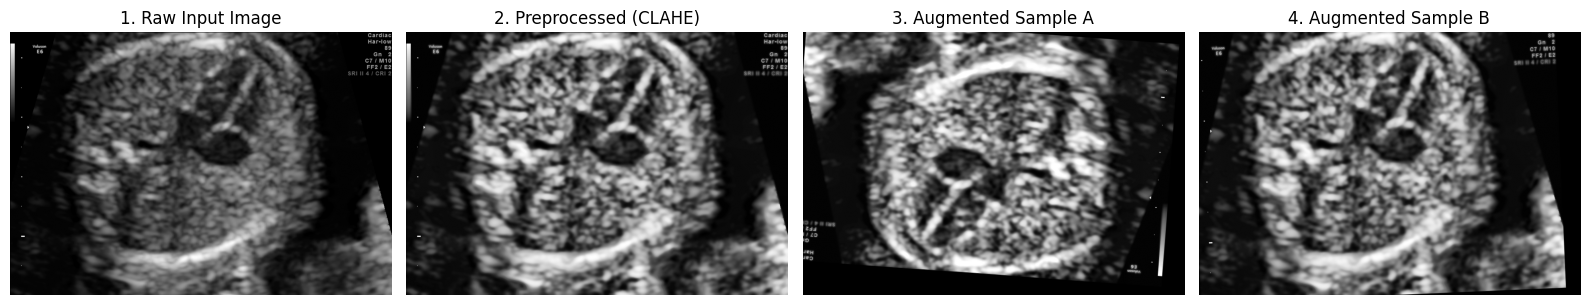

In [16]:
import cv2
import matplotlib.pyplot as plt

# Pick a sample image from your dataset
sample_img_path = glob.glob(os.path.join(RAW_ANNOTATED, "**", "*.png"), recursive=True)[0]

# Raw vs Preprocessed
raw_img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
preprocessed_img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
preprocessed_img = cv2.bilateralFilter(preprocessed_img, 9, 75, 75)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
preprocessed_img = clahe.apply(preprocessed_img)

# Generate Augmentations
import albumentations as A
aug_pipeline = A.Compose([
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.8),
    A.RandomBrightnessContrast(p=0.8)
])

aug1 = aug_pipeline(image=preprocessed_img)['image']
aug2 = aug_pipeline(image=preprocessed_img)['image']

# Display
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(raw_img, cmap='gray')
axes[0].set_title("1. Raw Input Image")

axes[1].imshow(preprocessed_img, cmap='gray')
axes[1].set_title("2. Preprocessed (CLAHE)")

axes[2].imshow(aug1, cmap='gray')
axes[2].set_title("3. Augmented Sample A")

axes[3].imshow(aug2, cmap='gray')
axes[3].set_title("4. Augmented Sample B")

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

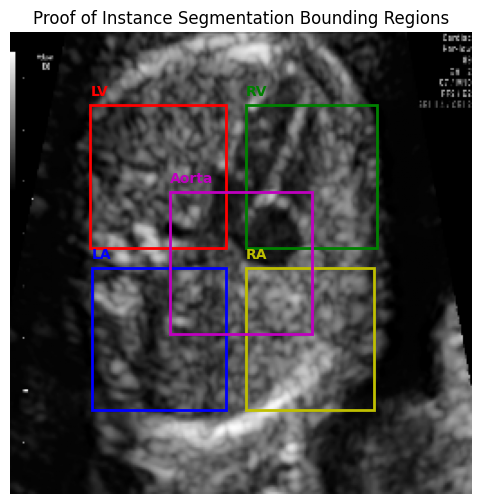


--- Extracted Feature Matrix Proof per Chamber ---


,Area,Perimeter,Circularity,Aspect Ratio,Eccentricity,Contrast,Energy,Homogeneity
LV,34.0,24.278175,0.724864,2.156614,0.885998,0.437500,0.423127,0.781250
RV,39.0,22.242641,0.990608,1.810486,0.833621,2.175000,0.174105,0.482500
LA,677.0,193.645707,0.226873,1.703169,0.809485,0.594320,0.232754,0.752333
RA,3287.0,844.879292,0.057866,1.527633,0.755969,0.544318,0.221720,0.763068
Aorta,297.0,130.083261,0.220558,1.200238,0.553020,0.701863,0.231625,0.708696


In [17]:
# Run feature extraction on a sample
feat_vec, chamber_feats, bboxes = process_image_and_annotations(sample_img_path)
img_gray = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
img_gray = cv2.resize(img_gray, (256, 256))

# Display Segmentation Overlay Proof
plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')

colors = {'LV': 'r', 'RV': 'g', 'LA': 'b', 'RA': 'y', 'Aorta': 'm'}
for ch, bbox in bboxes.items():
    x1, y1, x2, y2 = bbox
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=colors.get(ch, 'r'), linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(x1, max(10, y1 - 5), ch, color=colors.get(ch, 'r'), fontweight='bold')

plt.title("Proof of Instance Segmentation Bounding Regions")
plt.axis('off')
plt.show()

# Display Feature Extraction DataFrame
feature_names = ["Area", "Perimeter", "Circularity", "Aspect Ratio", "Eccentricity", "Contrast", "Energy", "Homogeneity"]
df_proof = pd.DataFrame([chamber_feats[ch] for ch in CHAMBERS], index=CHAMBERS, columns=feature_names)

print("\n--- Extracted Feature Matrix Proof per Chamber ---")
display(df_proof)

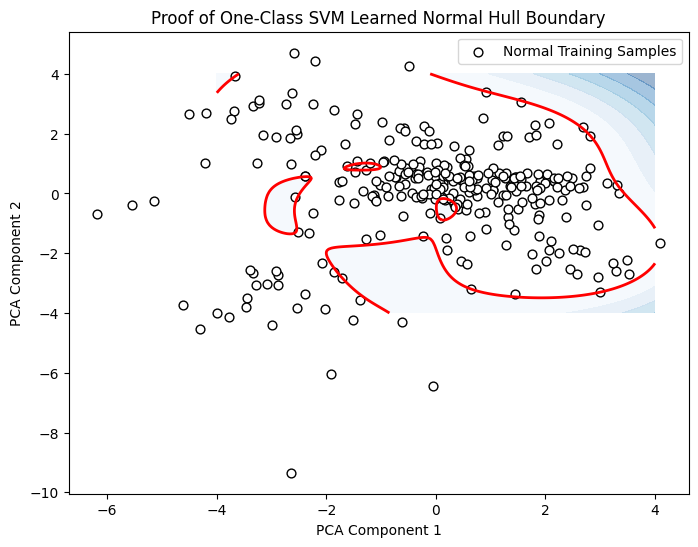

In [18]:
from sklearn.decomposition import PCA

# Reduce feature space to 2D for visual proof
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normal_scaled)

# Fit temporary 2D OC-SVM for plot visualization
svm_2d = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm_2d.fit(X_pca)

# Create grid to plot boundary hull
xx, yy = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-4, 4, 200))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.Blues_r, alpha=0.4)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='red') # Decision Boundary
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='white', edgecolors='k', s=40, label='Normal Training Samples')

plt.title("Proof of One-Class SVM Learned Normal Hull Boundary")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

=================== MODEL EVALUATION REPORT ===================
                  precision    recall  f1-score   support

CHD Anomaly (-1)       0.36      0.75      0.49        24
     Normal (+1)       0.98      0.89      0.93       300

        accuracy                           0.88       324
       macro avg       0.67      0.82      0.71       324
    weighted avg       0.93      0.88      0.90       324



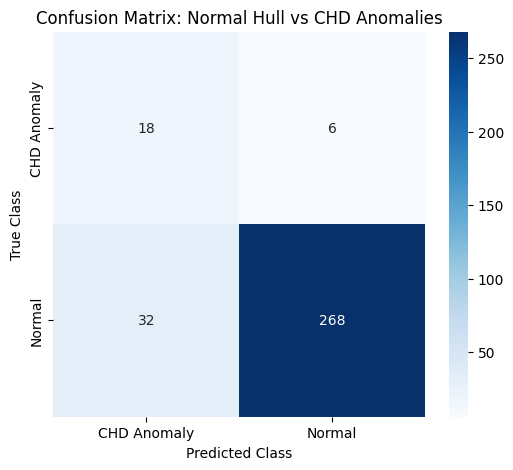

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

# Evaluate Normal Samples (+1)
for feat in X_normal_scaled:
    y_true.append(1)
    y_pred.append(oc_svm.predict([feat])[0])

# Evaluate CHD Anomaly Samples (-1)
chd_samples = glob.glob(os.path.join(CHD_TEST_DIR, "*.png")) + glob.glob(os.path.join(CHD_TEST_DIR, "*.jpg"))
for sample in chd_samples:
    feat_vec, _, _ = process_image_and_annotations(sample)
    if feat_vec is not None and len(feat_vec) > 0:
        scaled_feat = scaler.transform([feat_vec])
        y_true.append(-1)
        y_pred.append(oc_svm.predict(scaled_feat)[0])

# Print Classification Metrics
print("=================== MODEL EVALUATION REPORT ===================")
print(classification_report(y_true, y_pred, target_names=['CHD Anomaly (-1)', 'Normal (+1)']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['CHD Anomaly', 'Normal'], yticklabels=['CHD Anomaly', 'Normal'])
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix: Normal Hull vs CHD Anomalies")
plt.show()